In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

## Modelo standar

In [5]:
data = pd.read_excel("Datos_xgb.xlsx")
X = data.drop(columns=['SCC'])
y = data['SCC']  # Dependiente 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

mse, y_pred[:5]

(0.9252681241317606,
 array([4.16666667, 3.83333333, 3.33333333, 4.08333333, 2.91666667]))

### Modelo con GBoost standar

In [9]:
model_GB = GradientBoostingRegressor(random_state=42, n_estimators=100)
model_GB.fit(X_train, y_train)

# Predict on the test set using GBoost
y_model_GB_pred = model_GB.predict(X_test)

# Calculate the mean squared error (MSE) for the GBoost model
mse_GB = mean_squared_error(y_test, y_model_GB_pred)

mse_GB, y_model_GB_pred[:5]  # Return the MSE and the first 5 predictions


(0.606811835304652,
 array([2.62187019, 3.14501792, 3.78222454, 3.43802969, 3.10530187]))

In [17]:
# hyperparameters GridSearch
# https://scikit-learn.org/stable/modules/grid_search.html
# https://www.yourdatateacher.com/2021/05/19/hyperparameter-tuning-grid-search-and-random-search/
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

gboost = GradientBoostingRegressor(random_state=42)

# cross-validation (5-fold)
grid_search = GridSearchCV(estimator=gboost, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params_grid = grid_search.best_params_
best_score_grid = -grid_search.best_score_  # Convert negative MSE back to positive

In [15]:
best_params_grid

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

In [16]:
best_score_grid

0.4126251315400055

In [20]:
best_gboost_model = GradientBoostingRegressor(**best_params_grid, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
best_gboost_model.fit(X_train, y_train)

# Predecir con los datos de prueba
y_pred_best = best_gboost_model.predict(X_test)

# Evaluar el rendimiento con el MSE
from sklearn.metrics import mean_squared_error
mse_best = mean_squared_error(y_test, y_pred_best)

print(f"Mean Squared Error (MSE) del modelo optimizado: {mse_best}")

Mean Squared Error (MSE) del modelo optimizado: 0.5093102766863175


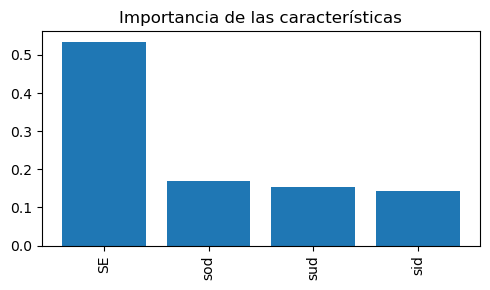

In [23]:
feature_importances = best_gboost_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(5, 3))
plt.title("Importancia de las características")
plt.bar(range(X_train.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


C:\Users\RR\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


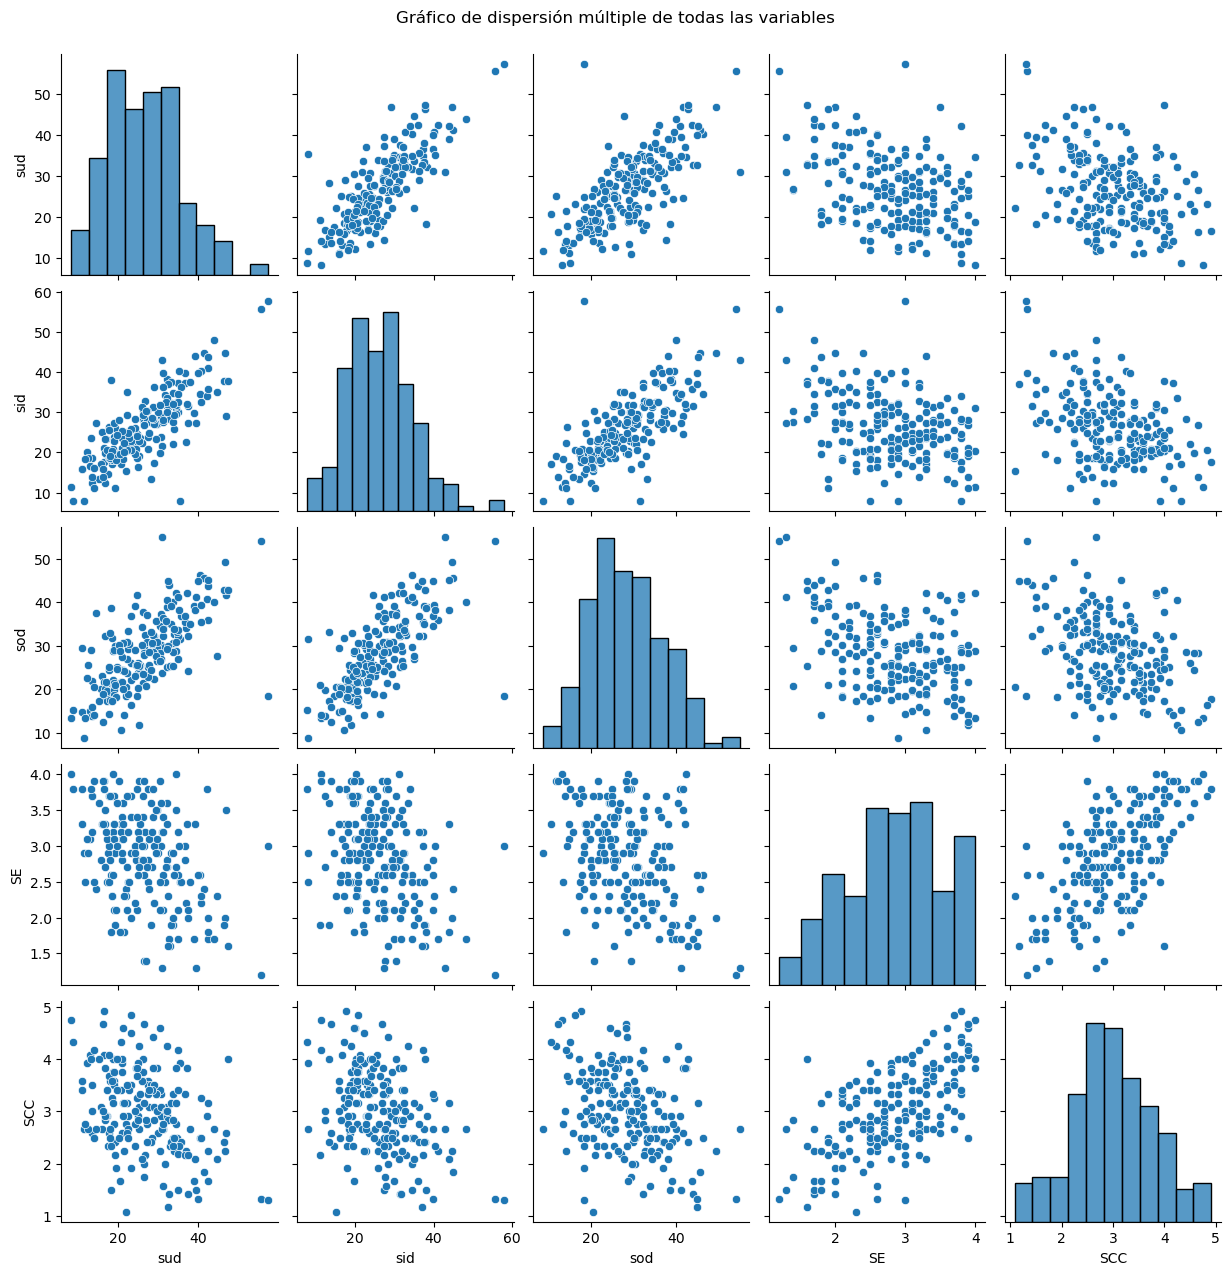

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data)
plt.suptitle('Gráfico de dispersión múltiple de todas las variables', y=1.02)
plt.show()
